
**VAE(Variational Autoencoder )**



Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0851
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0830
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0823
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0816
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0808
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0798
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0789
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0782
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0775
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0769


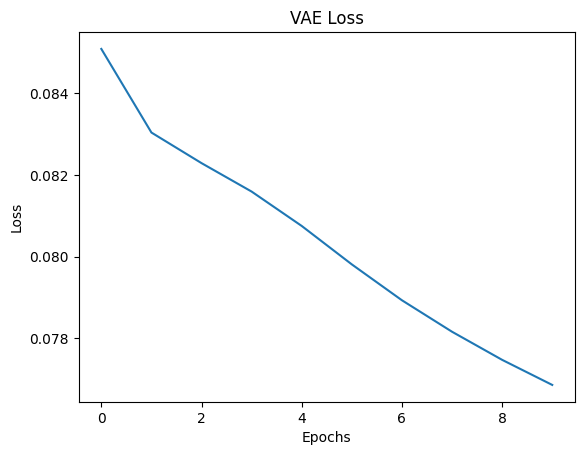

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

data = np.random.rand(1000, 20)

inputs = Input(shape=(20,))
encoded = Dense(10, activation='relu')(inputs)
latent = Dense(2)(encoded)
decoded = Dense(10, activation='relu')(latent)
outputs = Dense(20, activation='sigmoid')(decoded)

vae = Model(inputs, outputs)
vae.compile(optimizer='adam', loss='mse')

history = vae.fit(data, data, epochs=10, batch_size=32)

# Plot Loss
plt.plot(history.history['loss'])
plt.title("VAE Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

**GAN(Generative Adversarial Network )**

 1/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


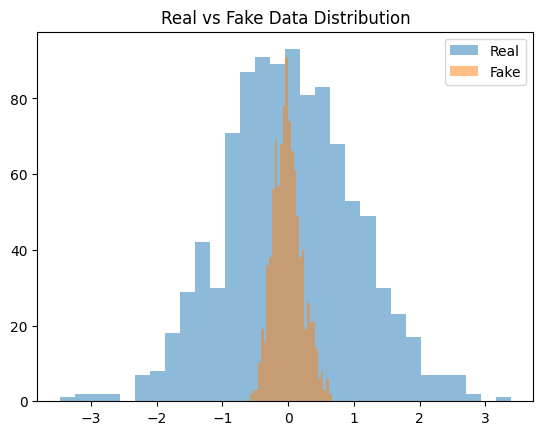

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

generator = Sequential([
    Dense(16, activation='relu', input_dim=10),
    Dense(1)
])

# Real data
real = np.random.normal(0, 1, 1000)

# Fake data
noise = np.random.rand(1000, 10)
fake = generator.predict(noise)

# Plot distributions
plt.hist(real, bins=30, alpha=0.5, label="Real")
plt.hist(fake, bins=30, alpha=0.5, label="Fake")
plt.legend()
plt.title("Real vs Fake Data Distribution")
plt.show()

**GCN(Graph Convolutional Network )**

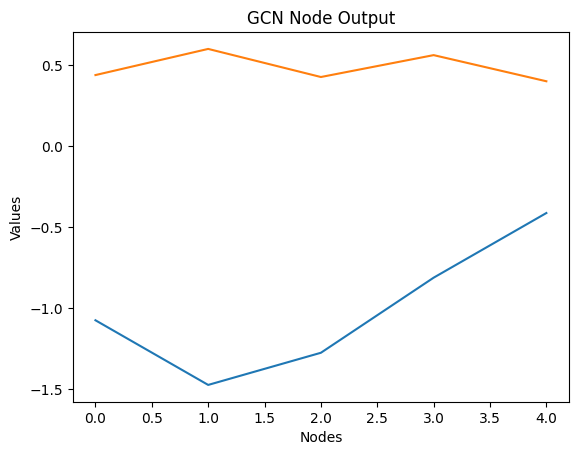

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

x = torch.rand(5, 10)

adj = torch.tensor([
    [1,1,0,0,0],
    [1,1,1,0,0],
    [0,1,1,1,0],
    [0,0,1,1,1],
    [0,0,0,1,1]
], dtype=torch.float32)

class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(10, 2)

    def forward(self, x, adj):
        x = torch.matmul(adj, x)
        return self.fc(x)

model = GCN()
output = model(x, adj).detach().numpy()

# Plot node outputs
plt.plot(output)
plt.title("GCN Node Output")
plt.xlabel("Nodes")
plt.ylabel("Values")
plt.show()